# 📊 Exploración Inicial de Datos

**Proyecto:** Asistente Inteligente de Lectura para Discapacidad Cognitiva  
**Objetivo:** Analizar textos de muestra y calcular métricas básicas

---

## 1️⃣ Importar Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Estilo visual consistente con el resto del proyecto
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2️⃣ Cargar Modelo de spaCy

In [ ]:
# Modelo español grande de spaCy: incluye vectores de palabras,
# análisis morfológico, etiquetado POS y análisis de dependencias.
# Necesario para calcular profundidad sintáctica con token.ancestors
nlp = spacy.load("es_core_news_lg")

print("✅ Modelo spaCy cargado: es_core_news_lg")
print(f"   Vocabulario: {len(nlp.vocab)} palabras")

✅ Modelo spaCy cargado: es_core_news_lg
   Vocabulario: 420 palabras


## 3️⃣ Textos de Ejemplo

**Niveles de dificultad:**
- Nivel 1: Muy fácil (Primaria 1º-2º)
- Nivel 2: Fácil (Primaria 3º-4º)
- Nivel 3: Medio (Primaria 5º-6º)
- Nivel 4: Difícil (ESO 1º-2º)
- Nivel 5: Muy difícil (ESO 3º-4º / Bachillerato)

In [4]:
# Textos de muestra para probar el sistema
textos_ejemplo = [
    {
        "texto": "El gato es pequeño. Tiene pelo suave. Le gusta jugar.",
        "nivel": 1,
        "fuente": "Ejemplo manual - Nivel 1"
    },
    {
        "texto": "Los animales del bosque viven en sus casas. El conejo vive en una madriguera bajo la tierra. El pájaro hace su nido en los árboles altos.",
        "nivel": 2,
        "fuente": "Ejemplo manual - Nivel 2"
    },
    {
        "texto": "El ciclo del agua es un proceso natural mediante el cual el agua se evapora de los océanos, forma nubes en la atmósfera y regresa a la tierra en forma de lluvia. Este ciclo es esencial para la vida en nuestro planeta.",
        "nivel": 3,
        "fuente": "Ejemplo manual - Nivel 3"
    },
    {
        "texto": "La fotosíntesis es el proceso bioquímico mediante el cual las plantas convierten la energía solar en energía química, utilizando dióxido de carbono y agua para producir glucosa y oxígeno como subproductos de esta reacción.",
        "nivel": 4,
        "fuente": "Ejemplo manual - Nivel 4"
    },
    {
        "texto": "La teoría de la relatividad especial, formulada por Albert Einstein en 1905, establece que las leyes de la física son invariantes en todos los sistemas de referencia inerciales y que la velocidad de la luz en el vacío es constante, independientemente del movimiento de la fuente luminosa o del observador.",
        "nivel": 5,
        "fuente": "Ejemplo manual - Nivel 5"
    }
]

df_ejemplo = pd.DataFrame(textos_ejemplo)
print(f"✅ {len(df_ejemplo)} textos de ejemplo cargados")
df_ejemplo

✅ 5 textos de ejemplo cargados


,texto,nivel,fuente
0,El gato es pequeño. Tiene pelo suave. Le gusta...,1,Ejemplo manual - Nivel 1
1,Los animales del bosque viven en sus casas. El...,2,Ejemplo manual - Nivel 2
2,El ciclo del agua es un proceso natural median...,3,Ejemplo manual - Nivel 3
3,La fotosíntesis es el proceso bioquímico media...,4,Ejemplo manual - Nivel 4
4,"La teoría de la relatividad especial, formulad...",5,Ejemplo manual - Nivel 5


## 4️⃣ Funciones de Análisis de Texto

In [ ]:
def calcular_metricas_texto(texto, nlp_model):
    """
    Calcula métricas lingüísticas básicas de un texto usando spaCy.
    
    Esta función corresponde al análisis exploratorio inicial (Iteración 0).
    En el pipeline final se sustituye por embeddings semánticos de 384 dims
    combinados con features lingüísticas calculadas sin spaCy para mayor velocidad.
    
    Args:
        texto (str): texto en español a analizar
        nlp_model: modelo spaCy cargado (es_core_news_lg)
        
    Returns:
        dict con métricas:
            - num_palabras (int): tokens sin puntuación
            - num_frases (int): frases detectadas por spaCy
            - num_caracteres (int): longitud total del texto
            - palabras_por_frase (float): complejidad sintáctica básica
            - caracteres_por_palabra (float): proxy de longitud léxica
            - diversidad_lexica (float): ratio tipos/tokens (TTR)
            - profundidad_sintactica (float): profundidad media del árbol de dependencias
    """
    doc = nlp_model(texto)
    
    # Contar tokens excluyendo puntuación
    num_palabras = len([token for token in doc if not token.is_punct])
    # spaCy detecta límites de frase mediante el componente 'senter'
    num_frases = len(list(doc.sents))
    num_caracteres = len(texto)
    
    palabras_por_frase = num_palabras / num_frases if num_frases > 0 else 0
    caracteres_por_palabra = num_caracteres / num_palabras if num_palabras > 0 else 0
    
    # TTR (Type-Token Ratio): ratio de lemas únicos sobre total de tokens
    # Valores más altos indican mayor riqueza léxica
    palabras_unicas = set([
        token.lemma_.lower() 
        for token in doc 
        if not token.is_punct and not token.is_space
    ])
    diversidad_lexica = len(palabras_unicas) / num_palabras if num_palabras > 0 else 0
    
    # Profundidad del árbol de dependencias: mide complejidad sintáctica real
    # token.ancestors devuelve todos los nodos superiores en el árbol
    profundidad_media = np.mean([
        len(list(token.ancestors)) for token in doc
    ]) if len(doc) > 0 else 0
    
    return {
        'num_palabras': num_palabras,
        'num_frases': num_frases,
        'num_caracteres': num_caracteres,
        'palabras_por_frase': round(palabras_por_frase, 2),
        'caracteres_por_palabra': round(caracteres_por_palabra, 2),
        'diversidad_lexica': round(diversidad_lexica, 3),
        'profundidad_sintactica': round(profundidad_media, 2)
    }

print("✅ Función calcular_metricas_texto() definida")

✅ Función calcular_metricas_texto() definida


## 5️⃣ Análisis de Textos de Ejemplo

In [ ]:
# Calcular métricas para todos los textos de ejemplo
metricas_lista = []

for idx, row in df_ejemplo.iterrows():
    metricas = calcular_metricas_texto(row['texto'], nlp)
    # Añadir nivel y fuente para poder agrupar en visualizaciones
    metricas['nivel'] = row['nivel']
    metricas['fuente'] = row['fuente']
    metricas_lista.append(metricas)

df_metricas = pd.DataFrame(metricas_lista)
print("✅ Métricas calculadas para todos los textos\n")
df_metricas

✅ Métricas calculadas para todos los textos



,num_palabras,num_frases,num_caracteres,palabras_por_frase,caracteres_por_palabra,diversidad_lexica,profundidad_sintactica,nivel,fuente
0,10,3,53,3.33,5.30,1.000,0.92,1,Ejemplo manual - Nivel 1
1,26,3,137,8.67,5.27,0.692,1.45,2,Ejemplo manual - Nivel 2
2,42,2,217,21.00,5.17,0.714,1.93,3,Ejemplo manual - Nivel 3
3,34,1,222,34.00,6.53,0.794,3.22,4,Ejemplo manual - Nivel 4
4,50,1,305,50.00,6.10,0.660,3.67,5,Ejemplo manual - Nivel 5


## 6️⃣ Visualizaciones

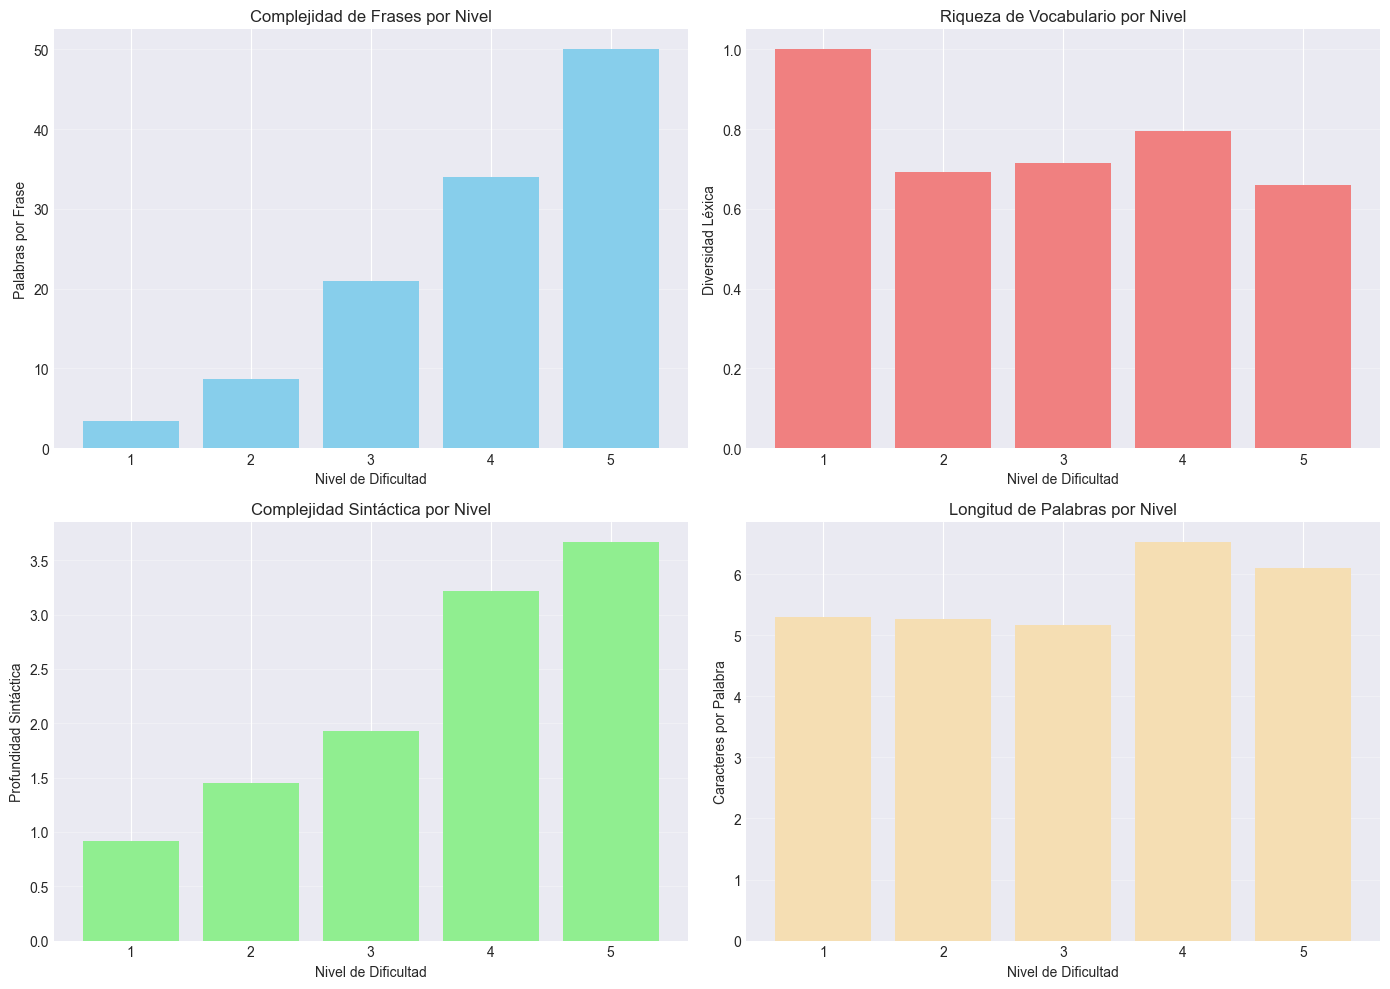

✅ Visualizaciones generadas


In [7]:
# Gráfico 1: Palabras por frase según nivel
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Palabras por frase
axes[0, 0].bar(df_metricas['nivel'], df_metricas['palabras_por_frase'], color='skyblue')
axes[0, 0].set_xlabel('Nivel de Dificultad')
axes[0, 0].set_ylabel('Palabras por Frase')
axes[0, 0].set_title('Complejidad de Frases por Nivel')
axes[0, 0].grid(axis='y', alpha=0.3)

# Diversidad léxica
axes[0, 1].bar(df_metricas['nivel'], df_metricas['diversidad_lexica'], color='lightcoral')
axes[0, 1].set_xlabel('Nivel de Dificultad')
axes[0, 1].set_ylabel('Diversidad Léxica')
axes[0, 1].set_title('Riqueza de Vocabulario por Nivel')
axes[0, 1].grid(axis='y', alpha=0.3)

# Profundidad sintáctica
axes[1, 0].bar(df_metricas['nivel'], df_metricas['profundidad_sintactica'], color='lightgreen')
axes[1, 0].set_xlabel('Nivel de Dificultad')
axes[1, 0].set_ylabel('Profundidad Sintáctica')
axes[1, 0].set_title('Complejidad Sintáctica por Nivel')
axes[1, 0].grid(axis='y', alpha=0.3)

# Caracteres por palabra
axes[1, 1].bar(df_metricas['nivel'], df_metricas['caracteres_por_palabra'], color='wheat')
axes[1, 1].set_xlabel('Nivel de Dificultad')
axes[1, 1].set_ylabel('Caracteres por Palabra')
axes[1, 1].set_title('Longitud de Palabras por Nivel')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualizaciones generadas")

## 7️⃣ Resumen de Resultados

In [8]:
print("📊 RESUMEN DE MÉTRICAS POR NIVEL")
print("=" * 60)

for nivel in sorted(df_metricas['nivel'].unique()):
    datos_nivel = df_metricas[df_metricas['nivel'] == nivel].iloc[0]
    
    print(f"\nNivel {nivel}:")
    print(f"  • Palabras por frase: {datos_nivel['palabras_por_frase']}")
    print(f"  • Diversidad léxica: {datos_nivel['diversidad_lexica']:.3f}")
    print(f"  • Profundidad sintáctica: {datos_nivel['profundidad_sintactica']:.2f}")
    print(f"  • Caracteres por palabra: {datos_nivel['caracteres_por_palabra']:.2f}")

print("\n" + "=" * 60)
print("✅ Sistema de análisis funcionando correctamente")
print("\n🎯 Próximos pasos:")
print("   1. Conseguir textos reales de tu amiga profesora")
print("   2. Guardarlos en data/raw/")
print("   3. Procesarlos con OCR si son fotos")
print("   4. Etiquetar por nivel de dificultad")
print("   5. Entrenar modelo de clasificación")

📊 RESUMEN DE MÉTRICAS POR NIVEL

Nivel 1:
  • Palabras por frase: 3.33
  • Diversidad léxica: 1.000
  • Profundidad sintáctica: 0.92
  • Caracteres por palabra: 5.30

Nivel 2:
  • Palabras por frase: 8.67
  • Diversidad léxica: 0.692
  • Profundidad sintáctica: 1.45
  • Caracteres por palabra: 5.27

Nivel 3:
  • Palabras por frase: 21.0
  • Diversidad léxica: 0.714
  • Profundidad sintáctica: 1.93
  • Caracteres por palabra: 5.17

Nivel 4:
  • Palabras por frase: 34.0
  • Diversidad léxica: 0.794
  • Profundidad sintáctica: 3.22
  • Caracteres por palabra: 6.53

Nivel 5:
  • Palabras por frase: 50.0
  • Diversidad léxica: 0.660
  • Profundidad sintáctica: 3.67
  • Caracteres por palabra: 6.10

✅ Sistema de análisis funcionando correctamente

🎯 Próximos pasos:
   1. Conseguir textos reales de tu amiga profesora
   2. Guardarlos en data/raw/
   3. Procesarlos con OCR si son fotos
   4. Etiquetar por nivel de dificultad
   5. Entrenar modelo de clasificación


## 8️⃣ Guardar Resultados (Opcional)

In [ ]:
# Guardar métricas en CSV para análisis posterior
output_path = Path("../data/processed/metricas_ejemplo.csv")
# Crear carpeta si no existe (parents=True para carpetas intermedias)
output_path.parent.mkdir(parents=True, exist_ok=True)

df_metricas.to_csv(output_path, index=False, encoding='utf-8')
print(f"✅ Métricas guardadas en: {output_path}")

✅ Métricas guardadas en: ..\data\processed\metricas_ejemplo.csv
